# Connect two consecutive sections
Suppose we have partitioned the input circuit $C$ into section $C_1, C_2, \ldots, C_k$, s.t. the Interaction graph of each $C_i$, written $IG(C_i)$, is embeddable into the architecture $AG$. We now need transform these subcircuits onto $AG$.

We implement $C$ as a dag, and obtain a list of sub-dagcircuits $dag_1, dag_2, \ldots, dag_k$ as the output of our partition function. Furthermore, we realign the boundary nodes of consecutive dags so that their graph connections are simpler. I believe this partition could unveil more (dynamic) graph properties of quantum circuits, e.g., change of their completeness, change of their centres, etc.

The aim of this note is to link these connective sections so that the number of SWAPs inserted is minimal. A standard approach is as follows: 
(i) we select an initial mapping $m_1$ for $C_1$ which is good embedding of $IG(C_1$) in certain sense; 
(ii) assume that we have transformed i sections and the final mapping is $m_i$ (which is an embedding of $IG(C_i)$), we should find an embedding $m_{i+1}$ for $IG(C_{i+1})$ and a set of SWAPs that link $m_i$ to $m_{i+1}$. 
The objective is to minimise the number of total SWAPs inserted. 

$IG(C_i) \Rightarrow IG(C_{i+1})$?


## The general case
Suppose we have two sections $C_1$ and $C_2$ and the initial mapping of $C_1$ is a trivial mapping $id_Q$. The task is to find an embedding $m$ of $C_2$ s.t. the routing cost from $id$ to $m$ is minimal among all embeddings of $C_2$. This requires to examine all embeddings of $C_2$ if we use approximate token swapper (ATS) directly.

In general, let $m_1$ be an embedding of $IG(C_1)$ and $m_2$ an embedding of $IG(C_2)$. How to call ATS?

Let $Q_1$, $Q_2$ be subsets of $V$ and $m_i: Q_i \to V$ two 1-1 mappings for $i=1,2$.  

First, we apply $m_1$ on all gates in $C$, such that if $CX(i,j)$ in $C$, then we put $CX(m_1(i),m_1(j))$ in $m_1(C)$. In this way, the trivial mapping $id$ can embed $IG(m_1(C_1))$ to $AG$.

In the following, we assume $m_1=id_{Q_1}$. One issue is that each $Q_i$ is a subset of $V$ and $Q_1$ and $Q_2$ sometimes partially overlap.

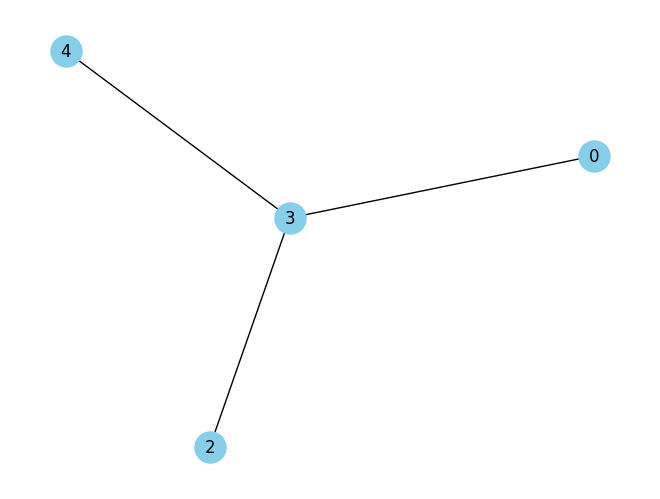
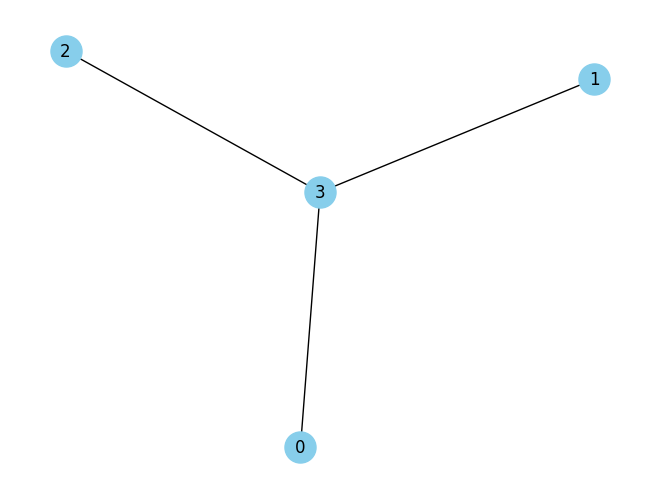

In [115]:
from qiskit.transpiler.passes.routing.algorithms.token_swapper import ApproximateTokenSwapper as ATS
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.transpiler.layout import Layout
from qiskit.circuit.quantumregister import Qubit
from qiskit.visualization import dag_drawer
from qiskit.qasm import Qasm

import matplotlib.pyplot as plt
import networkx as nx
import rustworkx as rx

In [153]:
def get_reverse_mapping(map1):
    revmap = dict()
    for key in map1:
        revmap[map1[key]] = key
    return revmap

""" get an rxgraph from a nxgraph"""
def get_rxgraph(graph):
    if not isinstance(graph,nx.Graph):
        raise Exception (f'The input {type(graph)} should be a nx.Graph')
    rxgraph = rx.PyGraph()
    rxedges = [(edge[0],edge[1],1) for edge in graph.edges()]
    rxgraph.add_nodes_from(graph.nodes())
    rxgraph.add_edges_from(rxedges)
    return rxgraph

def token_swap(permutation, rxAG):
    """permutation is interpreted as a node-to-token mapping, rxAG is the rx version of AG"""
    token_swapper = ATS(rxAG)
    #map1 = get_reverse_mapping(t2nmap)
    action = token_swapper.map(permutation)
    return action

def extend_map(tau1, tau2, rxAG, token):
    dist = rx.distance_matrix(rxAG)
    if token in tau1 or not(token in tau2): 
        raise Exception ('This case will be discussed later.')
    if tau2[token] not in tau1.values():
        print(f'extended {token, tau2[token]}')
        return tau2[token]

    m = len(rxAG.nodes())
    selected_node = None
    for node in rxAG.nodes():
        if node in tau1.values(): continue
        if int(dist[node, tau2[token]]) < m:
            m = int(dist[node, tau2[token]])
            selected_node = node
            
    print(f'extended {token, tau2[token]}')
    return selected_node

def ats_rotuer(tau1, tau2, rxAG):
    """//TODO: What if tau1 and tau2 are partial? (both are token-to-node mappings)
        We need to extend tau1 so that it also covers tokens of tau2."""
   
    print(f'tau1 = {tau1} and tau2 = {tau2}')
    for token in rxAG.nodes():
        if token not in tau1 and token in tau2:
            tau1[token] = extend_map(tau1, tau2, rxAG, token)
                    
        if token not in tau2 and token in tau1:
            tau2[token] = extend_map(tau2, tau1, rxAG, token)

    #Undefined_TOKEN = [token for token in rxAG.nodes() if token not in tau1]
    NonOccupied_NODE1 = [node for node in rxAG.nodes() if node not in tau1.values()]
    NonOccupied_NODE2 = [node for node in rxAG.nodes() if node not in tau2.values()]
    if len(NonOccupied_NODE1) != len(NonOccupied_NODE2):
        raise Exception (f'Undefined_TOKEN and NonOccupied_NODE do not match!')
    
    permutation = dict()    
    for i in range(len(NonOccupied_NODE1)):
        permutation[NonOccupied_NODE1[i]] = NonOccupied_NODE2[i]
        
    tau1_inv = get_reverse_mapping(tau1)
    for v in rxAG.nodes():
        if v in NonOccupied_NODE1: continue
        #print(f'node {v}')
        permutation[v] = tau2[tau1_inv[v]]
        
    print(f'the composed permutation is {permutation}')
    return token_swap(permutation , rxAG)

[(0, 1), (0, 2), (1, 3), (2, 3), (2, 4), (3, 5), (4, 5)]


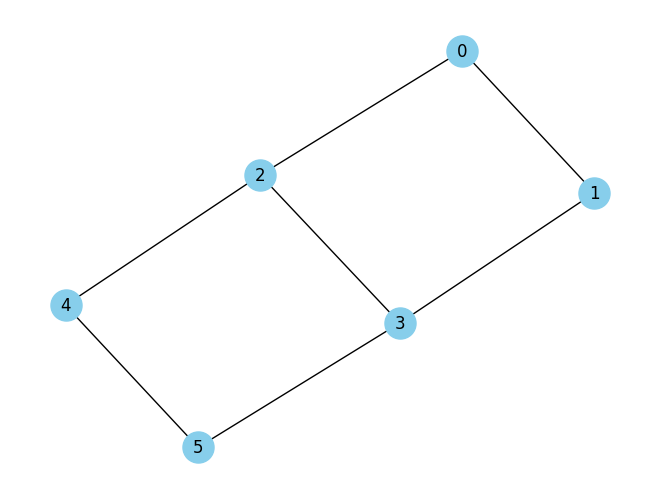

In [154]:
from ag import qgrid, q20
import time, copy, random

filename = 'and_5.qasm'

AG = qgrid(2,3)
#AG = q20()
print(AG.edges)
# Create a layout for the nodes
pos = nx.spring_layout(AG) #sl !!not sure if this is the correct layout for us!!
# Draw the nodes and edges
nx.draw(AG, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=12, font_color='black')
# Display the graph
plt.show()

rxAG = get_rxgraph(AG)

### An example
Let $AG$ be the Grid2$\times$3. Let $\pi = \{0: 3, 1: 1, 2: 4, 3: 2, 4: 0, 5: 5\}$ be a permutation on $V$, the node set of $AG$. We regard $\pi$ as a node-to-token mapping, i.e., for example, the token on node 0 is 3.

In [155]:
pi = {0: 3, 1: 1, 2: 4, 3: 2, 4: 0, 5: 5}
action = token_swap(pi, rxAG)
print(f'The permutation {pi} (regarded as a node-to-token mapping) can be implemented by \n {action}')
print('i.e., applying the SWAPs one by one will transform the permutation to the identity.')

The permutation {0: 3, 1: 1, 2: 4, 3: 2, 4: 0, 5: 5} (regarded as a node-to-token mapping) can be implemented by 
 EdgeList[(2, 4), (0, 2), (2, 3)]
i.e., applying the SWAPs one by one will transform the permutation to the identity.


The above transforamtion of permutation can be used to glue consecutive mappings. For example, let $\tau_i: Q_i\to V$ ($i=1,2$) be two token-to-node (partial) mappings. We want to find a sequence $S$ of SWAPs to transform $\tau_1$ to $\tau_2$. Let $\pi$ be the permutation that these SWAPs implement. Then we have $\tau_2 = \pi\circ\tau_1$. If $\tau_1$ is complete, we have $\pi = \tau_2\circ \tau_1^{-1}$. That is, to find $S$, we need only call token_swap for $\pi$. 

In this example, we have four tokens explicitly used 0, 2, 3, 4, and the locations of 0 and 4 are unknown in $\tau_1$. We assume that they (as well as token 1, 5) are in their ideal location (i.e., token 0 is in node 0, token 4 in node 4). This, however, is not necessarilly the optimal allocation. Indeed, if we extend $\tau_1$ as {4:0, 3:2, 0:4, 2:3}. We need only two SWAPs. 

In general, we extend $\tau_1$ as follows: Suppose $T_i$ (token $i$) in the key set of $\tau_2$ but not in that of $\tau_1$.
(i)  If $\tau_2(T_i)$ is not in the value set of $\tau_1$, then set $\tau_1(T_i)$ as $\tau_2(T_i)$.
(ii) Put $T_i$ on some node which could form a happy swap chain? How to implement this? Based on search? For simiplicity, we could put $T_i$ on a node which is closest to $\tau_2(T_i)$.

In [156]:
tau1 = {3:2}
tau2 = {4:0, 3:4, 0:3}
print(ats_rotuer(tau1, tau2, rxAG))

tau1 = {3: 2} and tau2 = {4: 0, 3: 4, 0: 3}
extended (0, 3)
extended (4, 0)
the composed permutation is {1: 1, 4: 2, 5: 5, 0: 0, 2: 4, 3: 3}
EdgeList[(2, 4)]


In [157]:
tau1x = {4:0, 3:2, 0:4, 2:3}
print(ats_rotuer(tau1x, tau2, rxAG))

tau1 = {4: 0, 3: 2, 0: 4, 2: 3} and tau2 = {4: 0, 3: 4, 0: 3}
extended (2, 3)
the composed permutation is {1: 2, 5: 5, 0: 0, 2: 4, 3: 1, 4: 3}
EdgeList[(3, 1), (4, 2), (2, 3)]


### Token Swapper
The implementation of arrproximate token swapping algorithm by Child's et al. requires a partial permutation $\pi$, which can be obtained, as we have shown above, if we have a mapping $\tau_1$ and another mapping $\tau_2$ so that $\pi$ can be defined as $\tau_2\circ \tau_1^{-1}$. If both $\tau_1$ and $\tau_2$ are complete, then $\pi$ is well-defined. In general, they may have many different possible extensions and our objective is to find the minimal number of SWAPs that can transform $\tau_1$ into $\tau_2$.

Recall that what we have are a sequence of sections or subgraphs. Suppose we have constructed $\tau_i$ for section $C_i$ or subgraph $g_i\equiv IG(C_i)$. What is the best $\tau_{i+1}$ for section $C_{i+1}$ or subgraph $g_{i+1}$? Continue our running example. From $\tau_1 = \{3:2,2:3\}$, we could further assign $T_4$ to node $1$ and $T_0$ to node $5$. This extension already embeds $g_2$, where $g_2$ is a subgraph with edges $(2,3),(2,4), (2,0)$.

#### An Exhaustive Search
Consider all embeddings for $C_1$ and $C_2$. Try all possible routing paths. 

Task 1: Given $\tau_1$ and $\tau_2$ two arbitrary embeddings of $IG(C_1)$ and $IG(C_2)$ onto $AG$. Compute the exact or a good approximation of the minimal number of SWAPs required to transform $\tau_1$ to $\tau_2$.

For convenience, we write $\tau_i: Q_i \to V_i$, where $Q_i, V_i$ are subsets of $V$ and $\tau_i$ is a bijection. If $p\in Q_1\setminus Q_2$, then where $\tau_2(p)$ is does not matter, but it seems rational to expect that it is not far from $\tau_1(p)$. There are the following cases:

1) $p\in Q_1\setminus Q_2$ and $\tau_1(p)\in V_1\setminus V_2$. We assume $\tau_2(p) = \tau_1(p)$.  
2) $p\in Q_1\setminus Q_2$ and $\tau_1(p)\in V_1\cap V_2$. Write $v_1=\tau_1(p)$. Since $v_1\in V_2$, we have $p'\in Q_2$ s.t. $\tau_2(p') = v_1$. This means we need to move $p$ at least one hop away.
3) $p\in Q_2\setminus Q_1$ and $u=\tau_2(p)\in V_1\setminus V_2$. We let $\tau_1(p)=u$.

#### Search based on SMT solver
We may select a good initial mapping for $C_1$, and then compute the mapping for $C_2$. 

Task 2: This can be achieved by a SMT solver.